In [591]:
#Import nedeed libries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

In [592]:
Full_data_light = pd.read_csv('players_data_light-2024_2025.csv')
Full_data_light.rename(lambda x : x+1)

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Att (GK),Thr,Launch%,AvgLen,Opp,Stp,Stp%,#OPA,#OPA/90,AvgDist
1,1,Max Aarons,eng ENG,DF,Bournemouth,eng Premier League,24.0,2000.0,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Max Aarons,eng ENG,"DF,MF",Valencia,es La Liga,24.0,2000.0,4,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Rodrigo Abajas,es ESP,DF,Valencia,es La Liga,21.0,2003.0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,James Abankwah,ie IRL,"DF,MF",Udinese,it Serie A,20.0,2004.0,6,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,18.0,2006.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2850,2850,Edhy Zuliani,fr FRA,DF,Toulouse,fr Ligue 1,19.0,2004.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2851,2851,Szymon Żurkowski,pl POL,MF,Empoli,it Serie A,26.0,1997.0,5,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2852,2852,Martin Ødegaard,no NOR,MF,Arsenal,eng Premier League,25.0,1998.0,30,26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2853,2853,Milan Đurić,ba BIH,FW,Monza,it Serie A,34.0,1990.0,18,13,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [593]:
# Filter the dataset to include only Midfielders (MF)
data_light = Full_data_light[Full_data_light['Pos'] == 'MF']
data_light.reset_index(drop=True).rename_axis(None).rename(lambda x: x+1)

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Att (GK),Thr,Launch%,AvgLen,Opp,Stp,Stp%,#OPA,#OPA/90,AvgDist
1,12,Nabil Aberdin,fr FRA,MF,Getafe,es La Liga,21.0,2002.0,7,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,13,Oliver Abildgaard,dk DEN,MF,Como,it Serie A,28.0,1996.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20,Federico Accornero,it ITA,MF,Genoa,it Serie A,20.0,2004.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,26,Tyler Adams,us USA,MF,Bournemouth,eng Premier League,25.0,1999.0,28,21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,29,Martin Adeline,fr FRA,MF,Reims,fr Ligue 1,20.0,2003.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
585,2839,Piotr Zieliński,pl POL,MF,Inter,it Serie A,30.0,1994.0,26,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
586,2846,Aristide Zossou,ci CIV,MF,Auxerre,fr Ligue 1,19.0,2005.0,3,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
587,2849,Martín Zubimendi,es ESP,MF,Real Sociedad,es La Liga,25.0,1999.0,36,33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
588,2851,Szymon Żurkowski,pl POL,MF,Empoli,it Serie A,26.0,1997.0,5,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [594]:
# Select key groups of columns for my MF analysis
basic_cols = [
    # --- Basic Player Information ---
    "Player", "Nation", "Pos", "Squad", "Comp", "Age", "Born",
    
    # --- Playing Time & Appearances ---
    "MP", "Starts", "Min", "90s",
    
    # --- Passing & Creativity ---
    "PrgP", "PrgC", "KP", "Cmp%", "Ast", "xA", "PPA",
    
    # --- Possession & Ball Control ---
    "Touches", "Carries", "PrgR", "Mis", "Dis"
]

# Create a lighter dataset with only those columns
data_light = data_light[basic_cols]

# Show the first few rows
data_light.reset_index(drop=True).rename_axis(None).rename(lambda x: x+1)

,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,...,KP,Cmp%,Ast,xA,PPA,Touches,Carries,PrgR,Mis,Dis
1,Nabil Aberdin,fr FRA,MF,Getafe,es La Liga,21.0,2002.0,7,4,263,...,1,59.0,0,0.1,2,87,34,2,1,1
2,Oliver Abildgaard,dk DEN,MF,Como,it Serie A,28.0,1996.0,1,0,7,...,0,100.0,0,0.0,0,2,0,0,0,0
3,Federico Accornero,it ITA,MF,Genoa,it Serie A,20.0,2004.0,1,0,5,...,0,66.7,0,0.0,0,8,5,0,2,0
4,Tyler Adams,us USA,MF,Bournemouth,eng Premier League,25.0,1999.0,28,21,1965,...,18,84.4,3,0.8,4,1337,663,10,28,12
5,Martin Adeline,fr FRA,MF,Reims,fr Ligue 1,20.0,2003.0,1,0,26,...,0,80.0,0,0.0,0,14,6,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
585,Piotr Zieliński,pl POL,MF,Inter,it Serie A,30.0,1994.0,26,8,980,...,14,89.5,2,1.0,6,803,510,24,8,6
586,Aristide Zossou,ci CIV,MF,Auxerre,fr Ligue 1,19.0,2005.0,3,0,16,...,0,88.9,0,0.0,1,21,14,3,0,1
587,Martín Zubimendi,es ESP,MF,Real Sociedad,es La Liga,25.0,1999.0,36,33,2962,...,19,83.6,1,1.3,23,2131,1074,43,39,17
588,Szymon Żurkowski,pl POL,MF,Empoli,it Serie A,26.0,1997.0,5,0,106,...,0,81.8,0,0.0,1,59,28,3,5,4


In [595]:
data_light.info()

<class 'pandas.core.frame.DataFrame'>
Index: 589 entries, 11 to 2851
Data columns (total 23 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Player   589 non-null    object 
 1   Nation   586 non-null    object 
 2   Pos      589 non-null    object 
 3   Squad    589 non-null    object 
 4   Comp     589 non-null    object 
 5   Age      588 non-null    float64
 6   Born     588 non-null    float64
 7   MP       589 non-null    int64  
 8   Starts   589 non-null    int64  
 9   Min      589 non-null    int64  
 10  90s      589 non-null    float64
 11  PrgP     589 non-null    int64  
 12  PrgC     589 non-null    int64  
 13  KP       589 non-null    int64  
 14  Cmp%     583 non-null    float64
 15  Ast      589 non-null    int64  
 16  xA       589 non-null    float64
 17  PPA      589 non-null    int64  
 18  Touches  589 non-null    int64  
 19  Carries  589 non-null    int64  
 20  PrgR     589 non-null    int64  
 21  Mis      589 non-nu

In [596]:
missing_values = data_light.isnull().sum()
missing_values = missing_values[missing_values>0]
missing_values

Nation    3
Age       1
Born      1
Cmp%      6
dtype: int64

In [597]:
# Fill missing values in Nation with 'Unknown'
data_light.loc[:,'Nation'] = data_light.fillna('Unk')
data_light.reset_index(drop=True).rename_axis(None).rename(lambda x: x+1)


,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,...,KP,Cmp%,Ast,xA,PPA,Touches,Carries,PrgR,Mis,Dis
1,Nabil Aberdin,fr FRA,MF,Getafe,es La Liga,21.0,2002.0,7,4,263,...,1,59.0,0,0.1,2,87,34,2,1,1
2,Oliver Abildgaard,dk DEN,MF,Como,it Serie A,28.0,1996.0,1,0,7,...,0,100.0,0,0.0,0,2,0,0,0,0
3,Federico Accornero,it ITA,MF,Genoa,it Serie A,20.0,2004.0,1,0,5,...,0,66.7,0,0.0,0,8,5,0,2,0
4,Tyler Adams,us USA,MF,Bournemouth,eng Premier League,25.0,1999.0,28,21,1965,...,18,84.4,3,0.8,4,1337,663,10,28,12
5,Martin Adeline,fr FRA,MF,Reims,fr Ligue 1,20.0,2003.0,1,0,26,...,0,80.0,0,0.0,0,14,6,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
585,Piotr Zieliński,pl POL,MF,Inter,it Serie A,30.0,1994.0,26,8,980,...,14,89.5,2,1.0,6,803,510,24,8,6
586,Aristide Zossou,ci CIV,MF,Auxerre,fr Ligue 1,19.0,2005.0,3,0,16,...,0,88.9,0,0.0,1,21,14,3,0,1
587,Martín Zubimendi,es ESP,MF,Real Sociedad,es La Liga,25.0,1999.0,36,33,2962,...,19,83.6,1,1.3,23,2131,1074,43,39,17
588,Szymon Żurkowski,pl POL,MF,Empoli,it Serie A,26.0,1997.0,5,0,106,...,0,81.8,0,0.0,1,59,28,3,5,4


In [598]:
# Fill age and born year by the mean of the values
mean_value = data_light[["Age","Born"]].mean().apply(ceil)
data_light[["Age", "Born"]] = data_light[["Age", "Born"]].fillna(mean_value)
data_light.reset_index(drop=True).rename_axis(None).rename(lambda x: x+1)

,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,...,KP,Cmp%,Ast,xA,PPA,Touches,Carries,PrgR,Mis,Dis
1,Nabil Aberdin,fr FRA,MF,Getafe,es La Liga,21.0,2002.0,7,4,263,...,1,59.0,0,0.1,2,87,34,2,1,1
2,Oliver Abildgaard,dk DEN,MF,Como,it Serie A,28.0,1996.0,1,0,7,...,0,100.0,0,0.0,0,2,0,0,0,0
3,Federico Accornero,it ITA,MF,Genoa,it Serie A,20.0,2004.0,1,0,5,...,0,66.7,0,0.0,0,8,5,0,2,0
4,Tyler Adams,us USA,MF,Bournemouth,eng Premier League,25.0,1999.0,28,21,1965,...,18,84.4,3,0.8,4,1337,663,10,28,12
5,Martin Adeline,fr FRA,MF,Reims,fr Ligue 1,20.0,2003.0,1,0,26,...,0,80.0,0,0.0,0,14,6,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
585,Piotr Zieliński,pl POL,MF,Inter,it Serie A,30.0,1994.0,26,8,980,...,14,89.5,2,1.0,6,803,510,24,8,6
586,Aristide Zossou,ci CIV,MF,Auxerre,fr Ligue 1,19.0,2005.0,3,0,16,...,0,88.9,0,0.0,1,21,14,3,0,1
587,Martín Zubimendi,es ESP,MF,Real Sociedad,es La Liga,25.0,1999.0,36,33,2962,...,19,83.6,1,1.3,23,2131,1074,43,39,17
588,Szymon Żurkowski,pl POL,MF,Empoli,it Serie A,26.0,1997.0,5,0,106,...,0,81.8,0,0.0,1,59,28,3,5,4


In [599]:
# Fill the Cmp% by the median for more accurate results
data_light["Cmp%"].fillna(data_light["Cmp%"].median(), inplace=True)
data_light["Cmp%"].reset_index(drop=True).rename_axis(None).rename(lambda x: x+1)



C:\Users\ancir\AppData\Local\Temp\ipykernel_15276\4216440799.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_light["Cmp%"].fillna(data_light["Cmp%"].median(), inplace=True)


1       59.0
2      100.0
3       66.7
4       84.4
5       80.0
       ...  
585     89.5
586     88.9
587     83.6
588     81.8
589     82.5
Name: Cmp%, Length: 589, dtype: float64

In [600]:
#For more enhancement to our data
# Extract the last country name from the Nation column
data_light['Nation'] = data_light['Nation'].apply(lambda x: x.split()[-1])
#reset index to 1
data_light.reset_index(drop=True).rename(lambda x: x+1)

,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,...,KP,Cmp%,Ast,xA,PPA,Touches,Carries,PrgR,Mis,Dis
1,Nabil Aberdin,FRA,MF,Getafe,es La Liga,21.0,2002.0,7,4,263,...,1,59.0,0,0.1,2,87,34,2,1,1
2,Oliver Abildgaard,DEN,MF,Como,it Serie A,28.0,1996.0,1,0,7,...,0,100.0,0,0.0,0,2,0,0,0,0
3,Federico Accornero,ITA,MF,Genoa,it Serie A,20.0,2004.0,1,0,5,...,0,66.7,0,0.0,0,8,5,0,2,0
4,Tyler Adams,USA,MF,Bournemouth,eng Premier League,25.0,1999.0,28,21,1965,...,18,84.4,3,0.8,4,1337,663,10,28,12
5,Martin Adeline,FRA,MF,Reims,fr Ligue 1,20.0,2003.0,1,0,26,...,0,80.0,0,0.0,0,14,6,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
585,Piotr Zieliński,POL,MF,Inter,it Serie A,30.0,1994.0,26,8,980,...,14,89.5,2,1.0,6,803,510,24,8,6
586,Aristide Zossou,CIV,MF,Auxerre,fr Ligue 1,19.0,2005.0,3,0,16,...,0,88.9,0,0.0,1,21,14,3,0,1
587,Martín Zubimendi,ESP,MF,Real Sociedad,es La Liga,25.0,1999.0,36,33,2962,...,19,83.6,1,1.3,23,2131,1074,43,39,17
588,Szymon Żurkowski,POL,MF,Empoli,it Serie A,26.0,1997.0,5,0,106,...,0,81.8,0,0.0,1,59,28,3,5,4


In [601]:
data_light

,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,...,KP,Cmp%,Ast,xA,PPA,Touches,Carries,PrgR,Mis,Dis
11,Nabil Aberdin,FRA,MF,Getafe,es La Liga,21.0,2002.0,7,4,263,...,1,59.0,0,0.1,2,87,34,2,1,1
12,Oliver Abildgaard,DEN,MF,Como,it Serie A,28.0,1996.0,1,0,7,...,0,100.0,0,0.0,0,2,0,0,0,0
19,Federico Accornero,ITA,MF,Genoa,it Serie A,20.0,2004.0,1,0,5,...,0,66.7,0,0.0,0,8,5,0,2,0
25,Tyler Adams,USA,MF,Bournemouth,eng Premier League,25.0,1999.0,28,21,1965,...,18,84.4,3,0.8,4,1337,663,10,28,12
28,Martin Adeline,FRA,MF,Reims,fr Ligue 1,20.0,2003.0,1,0,26,...,0,80.0,0,0.0,0,14,6,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2838,Piotr Zieliński,POL,MF,Inter,it Serie A,30.0,1994.0,26,8,980,...,14,89.5,2,1.0,6,803,510,24,8,6
2845,Aristide Zossou,CIV,MF,Auxerre,fr Ligue 1,19.0,2005.0,3,0,16,...,0,88.9,0,0.0,1,21,14,3,0,1
2848,Martín Zubimendi,ESP,MF,Real Sociedad,es La Liga,25.0,1999.0,36,33,2962,...,19,83.6,1,1.3,23,2131,1074,43,39,17
2850,Szymon Żurkowski,POL,MF,Empoli,it Serie A,26.0,1997.0,5,0,106,...,0,81.8,0,0.0,1,59,28,3,5,4


In [602]:
#Context of our players
## Nation level summary
nation_summary = data_light.groupby('Nation').agg(
    num_players=('Player','count'),
    avg_age=('Age','median'),
    min_age=('Age','min'),
    max_age=('Age','max')
).reset_index().rename(lambda x: x+1)
nation_summary


,Nation,num_players,avg_age,min_age,max_age
1,ALB,3,22.0,20.0,28.0
2,ALG,6,26.0,24.0,30.0
3,ARG,15,25.0,21.0,36.0
4,ARM,1,35.0,35.0,35.0
5,AUS,3,31.0,25.0,31.0
...,...,...,...,...,...
64,USA,8,23.0,21.0,26.0
65,Unk,3,25.0,23.0,27.0
66,VEN,2,25.0,24.0,26.0
67,WAL,1,20.0,20.0,20.0


In [603]:
## Squad level summary
squad_summary = data_light.groupby('Squad').agg(
    num_players=('Player','count'),
    avg_age=('Age','median')
).reset_index().rename(lambda x: x+1)
squad_summary

,Squad,num_players,avg_age
1,Alavés,4,26.5
2,Angers,6,27.0
3,Arsenal,3,25.0
4,Aston Villa,5,27.0
5,Atalanta,7,24.0
...,...,...,...
92,Villarreal,8,25.0
93,Werder Bremen,5,25.0
94,West Ham,6,27.5
95,Wolfsburg,6,25.5


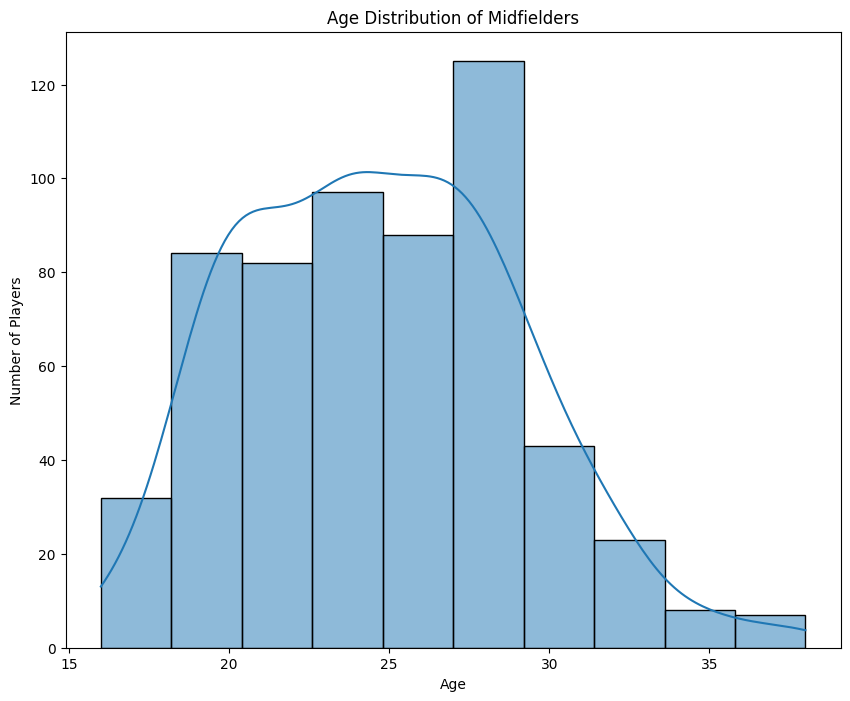

In [604]:
##Age distribution plot
plt.figure(figsize=(10,8))
sns.histplot(data=data_light['Age'],bins=10, kde=True)
plt.title("Age Distribution of Midfielders")
plt.xlabel("Age")
plt.ylabel("Number of Players")
plt.show()


In [605]:
# Passing & Creativity Analysis
'''for more accuracy Dividing by 90s gives per-game averages'''
for col in ['Ast','xA','KP','PrgP','PrgC','PPA']:
    data_light[col + '_per90'] = (data_light[col] / data_light['90s'].replace(0,np.nan)).fillna(0).round(3)

'''creativity efficiency'''
data_light['creativity_efficiency'] = data_light['xA_per90'] / (data_light['PrgP_per90'] )
data_light['creativity_efficiency']=data_light['creativity_efficiency'].fillna(0).round(3)
#explanation :: of all progessie passes a player makes how many actually lead to expected assists

'''Shot involvement ratio'''
data_light['shot_involvement_ratio'] = data_light['PPA_per90'] / (data_light['PrgP_per90'] + data_light['PrgC_per90'])
data_light['shot_involvement_ratio'] = data_light['shot_involvement_ratio'].fillna(0).round(3)
#explanation :: Of all the times a player moves the ball forward how often does it end with a pass into the penalty area

data_light.reset_index(drop=True).rename(lambda x: x+1)

,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,...,Mis,Dis,Ast_per90,xA_per90,KP_per90,PrgP_per90,PrgC_per90,PPA_per90,creativity_efficiency,shot_involvement_ratio
1,Nabil Aberdin,FRA,MF,Getafe,es La Liga,21.0,2002.0,7,4,263,...,1,1,0.000,0.034,0.345,2.069,0.690,0.690,0.016,0.250
2,Oliver Abildgaard,DEN,MF,Como,it Serie A,28.0,1996.0,1,0,7,...,0,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,Federico Accornero,ITA,MF,Genoa,it Serie A,20.0,2004.0,1,0,5,...,2,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,Tyler Adams,USA,MF,Bournemouth,eng Premier League,25.0,1999.0,28,21,1965,...,28,12,0.138,0.037,0.826,3.486,0.642,0.183,0.011,0.044
5,Martin Adeline,FRA,MF,Reims,fr Ligue 1,20.0,2003.0,1,0,26,...,0,0,0.000,0.000,0.000,0.000,3.333,0.000,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
585,Piotr Zieliński,POL,MF,Inter,it Serie A,30.0,1994.0,26,8,980,...,8,6,0.183,0.092,1.284,5.963,2.385,0.550,0.015,0.066
586,Aristide Zossou,CIV,MF,Auxerre,fr Ligue 1,19.0,2005.0,3,0,16,...,0,1,0.000,0.000,0.000,10.000,5.000,5.000,0.000,0.333
587,Martín Zubimendi,ESP,MF,Real Sociedad,es La Liga,25.0,1999.0,36,33,2962,...,39,17,0.030,0.040,0.578,5.927,1.155,0.699,0.007,0.099
588,Szymon Żurkowski,POL,MF,Empoli,it Serie A,26.0,1997.0,5,0,106,...,5,4,0.000,0.000,0.000,0.833,0.833,0.833,0.000,0.500


In [606]:
##Nation level average per 90
nation_creativity = data_light.groupby('Nation').agg(
    Ast_per90_avg=('Ast_per90','mean'),
    xA_per90_avg=('xA_per90','mean'),
    KP_per90_avg=('KP_per90','mean'),
    PrgP_per90_avg=('PrgP_per90','mean'),
    PrgC_per90_avg=('PrgC_per90','mean'),
    PPA_per90_avg=('PPA_per90','mean'),
    Cmp_avg=('Cmp%','mean'),
    creativity_efficiency_avg=('creativity_efficiency','mean'),##
    shot_involvement_ratio_avg=('shot_involvement_ratio','mean')##
).reset_index().round(3)
nation_creativity.reset_index(drop=True).rename(lambda x : x+1)

,Nation,Ast_per90_avg,xA_per90_avg,KP_per90_avg,PrgP_per90_avg,PrgC_per90_avg,PPA_per90_avg,Cmp_avg,creativity_efficiency_avg,shot_involvement_ratio_avg
1,ALB,0.119,0.098,1.182,4.427,0.905,0.867,83.100,0.020,0.152
2,ALG,0.073,0.120,0.934,6.038,1.842,1.024,87.417,0.020,0.120
3,ARG,0.119,0.110,1.885,10.053,4.677,1.517,84.200,0.022,0.120
4,ARM,0.154,0.158,1.120,7.683,2.780,2.046,87.400,0.021,0.196
5,AUS,0.069,0.122,1.034,3.987,1.418,1.071,76.367,0.025,0.135
...,...,...,...,...,...,...,...,...,...,...
64,USA,0.023,0.048,0.418,2.657,1.140,0.390,77.862,0.012,0.073
65,Unk,0.046,0.029,0.172,1.604,0.218,0.206,66.633,0.006,0.038
66,VEN,0.110,0.086,0.788,4.324,1.134,0.643,80.050,0.020,0.118
67,WAL,0.076,0.130,1.832,5.115,1.603,0.916,84.100,0.025,0.136


In [607]:
#Top nations by creativity efficiency
top_nations_efficiency = nation_creativity.sort_values('creativity_efficiency_avg', ascending=False)
top_nations_efficiency.head(10).reset_index(drop=True).rename(lambda x : x+1)

,Nation,Ast_per90_avg,xA_per90_avg,KP_per90_avg,PrgP_per90_avg,PrgC_per90_avg,PPA_per90_avg,Cmp_avg,creativity_efficiency_avg,shot_involvement_ratio_avg
1,FRA,0.068,0.093,0.873,4.373,1.576,0.665,81.247,inf,0.109
2,ZIM,0.106,0.096,1.011,1.383,0.426,0.266,68.500,0.069,0.147
3,LTU,0.063,0.138,1.321,2.264,0.943,0.440,74.700,0.061,0.137
4,ROU,0.064,1.112,21.090,17.692,10.705,10.641,78.050,0.055,0.294
5,KOR,0.186,0.182,1.340,3.734,1.324,0.967,77.700,0.048,0.188
6,CAN,0.209,0.120,0.828,3.155,2.982,0.482,74.600,0.048,0.077
7,PAR,0.000,0.211,1.404,4.737,1.404,1.228,80.500,0.045,0.200
8,BIH,0.047,0.081,0.758,2.370,1.754,0.332,77.700,0.034,0.081
9,TUN,0.160,0.110,1.348,3.719,0.996,1.066,81.400,0.033,0.233
10,HUN,0.115,0.119,1.123,3.551,1.432,0.839,79.333,0.031,0.174


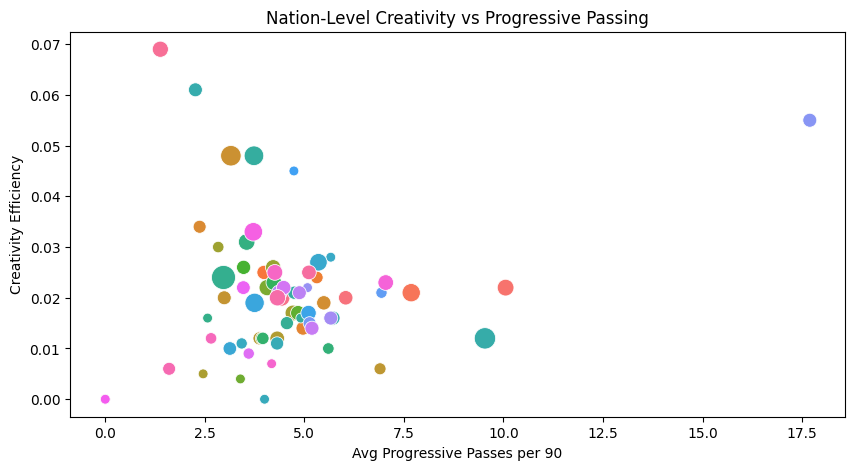

In [608]:
### Top nation by creativity efficiency
plt.figure(figsize=(10,5))
sns.scatterplot(
    x='PrgP_per90_avg',
    y='creativity_efficiency_avg',
    data=nation_creativity,
    size='Ast_per90_avg',
    hue='Nation',
    legend=False,
    sizes=(50,300)
)
plt.xlabel("Avg Progressive Passes per 90")
plt.ylabel("Creativity Efficiency")
plt.title("Nation-Level Creativity vs Progressive Passing")
plt.show()


In [609]:
#Possession and Ball control
possession =['Touches','Carries','PrgR','Mis','Dis']

In [610]:
##Average possession per Nation
nation_possession = data_light.groupby('Nation')[possession].agg('mean').sort_values('Touches', ascending=False).reset_index().rename(lambda x: x+1)
nation_possession




,Nation,Touches,Carries,PrgR,Mis,Dis
1,ARM,1747.000000,1036.000000,93.000000,27.000000,15.000000
2,SVK,1684.333333,856.666667,56.333333,37.333333,19.000000
3,EGY,1683.000000,852.000000,13.000000,17.000000,13.000000
4,VEN,1566.000000,842.500000,72.500000,46.500000,23.500000
5,BRA,1461.454545,823.909091,45.454545,28.818182,24.909091
...,...,...,...,...,...,...
64,CAN,192.333333,115.000000,22.666667,10.666667,4.333333
65,COL,190.500000,120.000000,8.500000,4.500000,5.000000
66,MKD,28.000000,13.000000,2.000000,0.000000,2.000000
67,ECU,8.000000,6.000000,2.000000,1.000000,0.000000


C:\Users\ancir\AppData\Local\Temp\ipykernel_15276\1763865933.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nation_possession['Nation'], y=nation_possession['Touches'],palette='viridis')


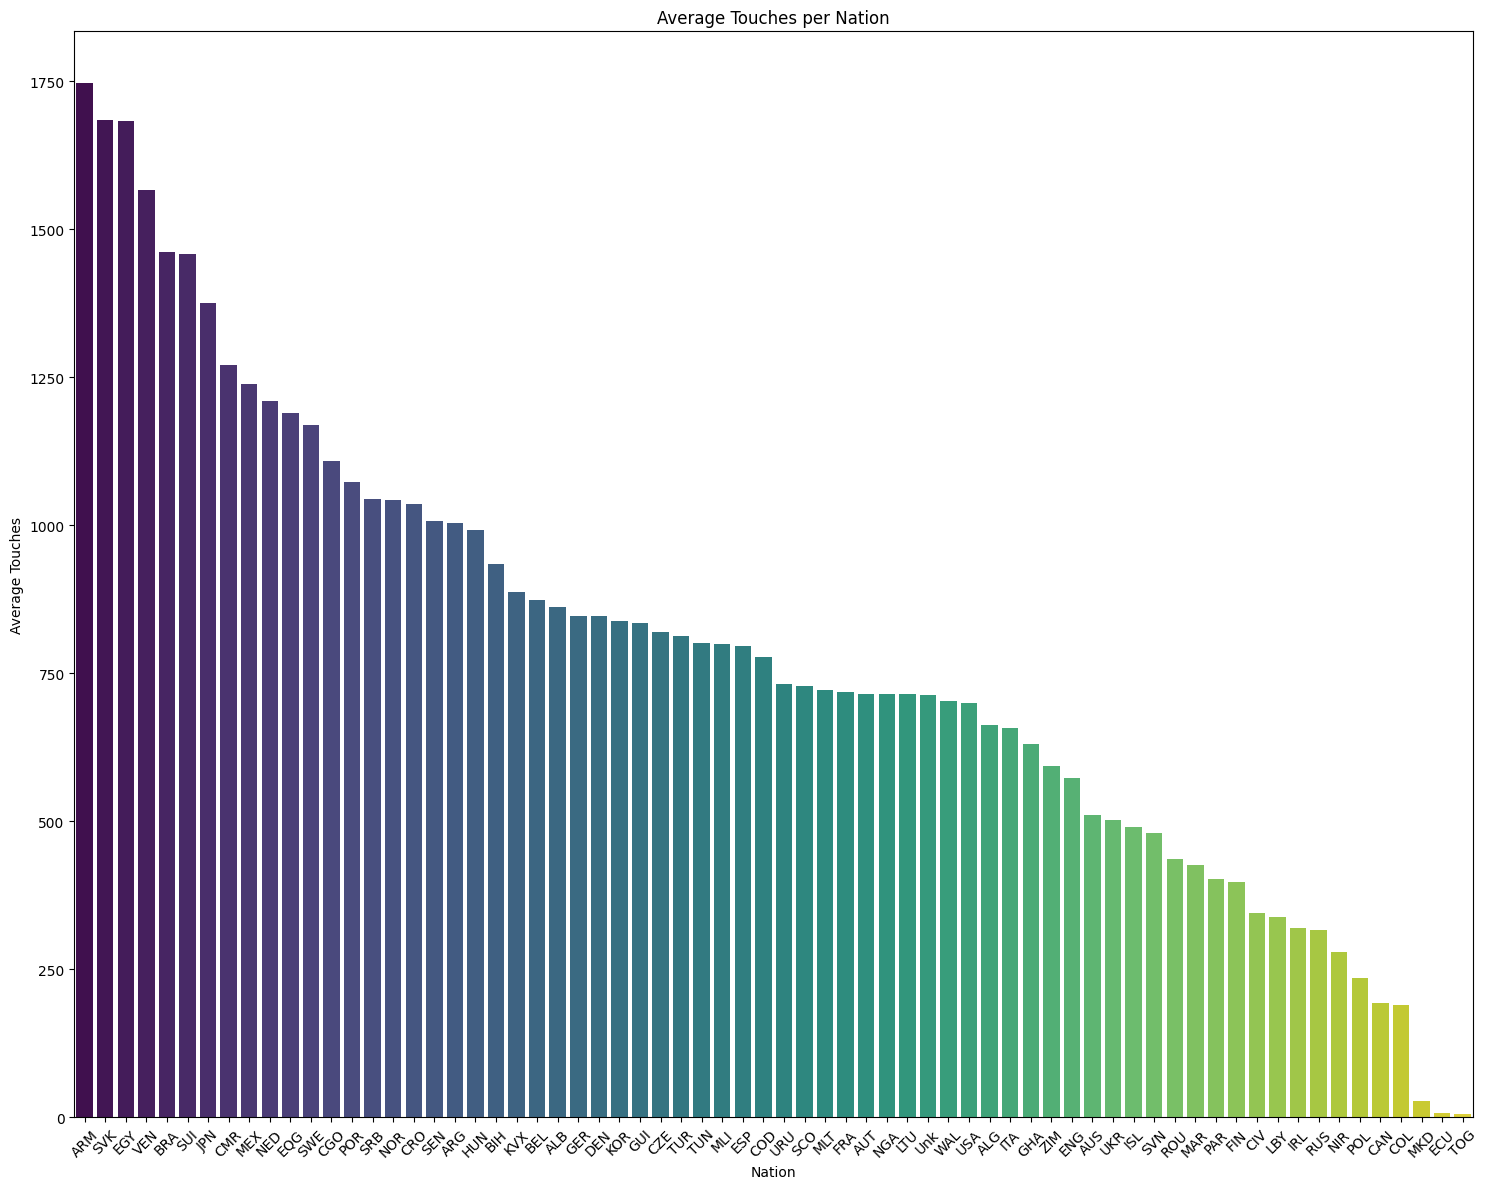

In [611]:
### Visualization: Average touches per nation
plt.figure(figsize=(15,12))
sns.barplot(x=nation_possession['Nation'], y=nation_possession['Touches'],palette='viridis')
plt.xticks(rotation=45)
plt.title("Average Touches per Nation")
plt.ylabel("Average Touches")
plt.xlabel('Nation')
plt.tight_layout()
plt.show()

In [612]:
##Average possession per Squad
squad_possession = data_light.groupby('Squad')[possession].agg('mean').sort_values('Touches', ascending=False).reset_index().rename(lambda x : x+1)
squad_possession



,Squad,Touches,Carries,PrgR,Mis,Dis
1,Paris S-G,1660.000000,1044.666667,68.333333,25.000000,18.666667
2,Barcelona,1501.500000,948.500000,46.500000,18.000000,13.250000
3,Bayern Munich,1487.600000,913.400000,55.200000,21.600000,9.800000
4,Leverkusen,1474.250000,791.500000,45.750000,13.750000,11.750000
5,Arsenal,1388.000000,835.666667,84.666667,28.666667,27.000000
...,...,...,...,...,...,...
92,Heidenheim,457.333333,227.000000,12.000000,11.500000,6.500000
93,Empoli,454.100000,205.000000,24.600000,14.600000,9.000000
94,Auxerre,447.111111,263.444444,28.333333,15.555556,13.000000
95,Nice,413.857143,221.142857,21.571429,12.857143,8.428571


C:\Users\ancir\AppData\Local\Temp\ipykernel_15276\219902484.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Squad', y='Touches', data=top_squads,palette='magma')


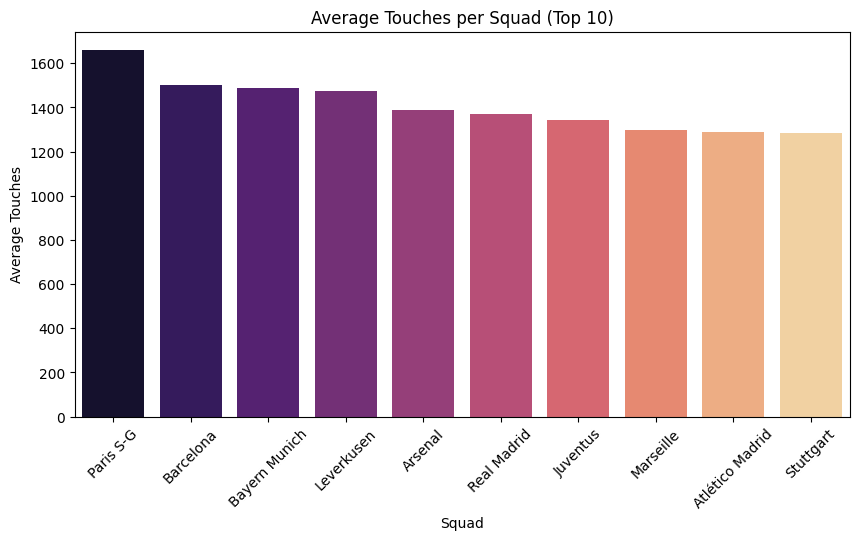

In [613]:
###Visualization: Average touches per squad (Top 10)
top_squads = squad_possession.head(10)
plt.figure(figsize=(10,5))
sns.barplot(x='Squad', y='Touches', data=top_squads,palette='magma')
plt.xticks(rotation=45)
plt.title("Average Touches per Squad (Top 10)")
plt.ylabel("Average Touches")
plt.show()

In [614]:
#Player Ranking by Creativity & Passing
##Top 10 creative players (xA per 90)
top_creators = data_light.sort_values('xA_per90', ascending=False)[
    ['Player','Squad','xA_per90','KP_per90','Ast_per90']].head(10).reset_index(drop=True).rename(lambda x: x+1)
top_creators

,Player,Squad,xA_per90,KP_per90,Ast_per90
1,Jakub Moder,Brighton,5.000,30.000,0.0
2,Rareş Ilie,Nice,2.000,40.000,0.0
3,Tommaso Rubino,Fiorentina,1.000,10.000,0.0
4,Ben Viadere,Auxerre,1.000,10.000,0.0
5,Jon Magunazelaia,Real Sociedad,1.000,0.000,0.0
6,Wylan Cyprien,Parma,0.667,0.000,0.0
7,Carney Chukwuemeka,Dortmund,0.643,2.500,0.0
8,Joshua King,Fulham,0.500,2.143,0.0
9,Philip Billing,Bournemouth,0.500,4.500,0.0
10,Nabil Fekir,Betis,0.400,3.000,0.5


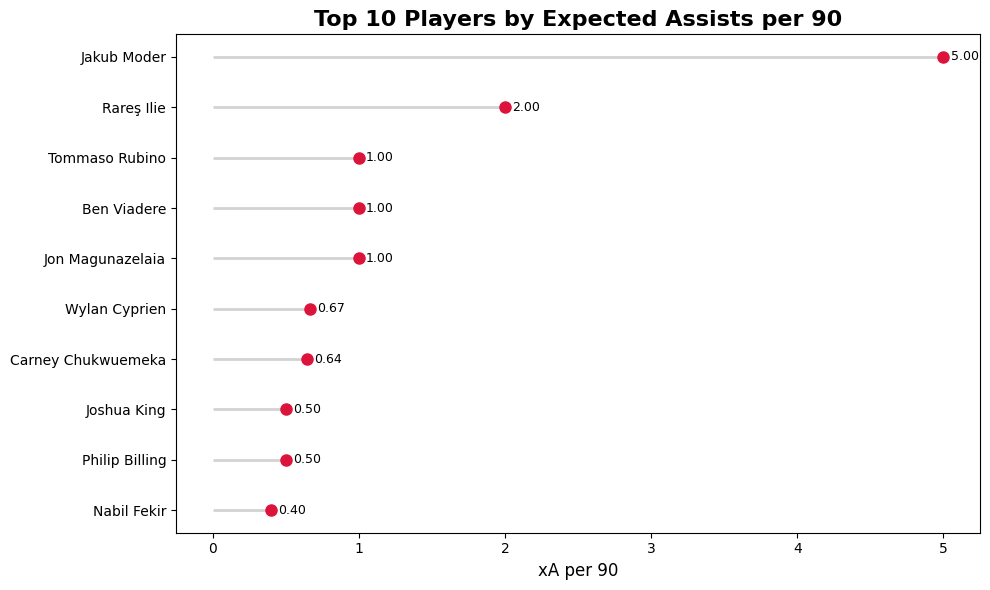

In [615]:
###Visualization: Top 10 xA per 90
plt.figure(figsize=(10,6))
plt.hlines(y=top_creators['Player'], xmin=0, xmax=top_creators['xA_per90'], color='lightgray', lw=2)
plt.plot(top_creators['xA_per90'], top_creators['Player'], "o", markersize=8, color="crimson")

# Add value labels
for i, row in top_creators.iterrows():
    plt.text(row['xA_per90'] + 0.05, row['Player'],
             f"{row['xA_per90']:.2f}", va='center', fontsize=9)

# Invert y-axis so highest is on top
plt.gca().invert_yaxis()

# Titles and labels
plt.title("Top 10 Players by Expected Assists per 90", fontsize=16, weight='bold')
plt.xlabel("xA per 90", fontsize=12)
plt.ylabel("")
plt.tight_layout()
plt.show()


In [616]:
##Top 10 key passers
top_keypass = data_light.sort_values('KP_per90', ascending=False)[
    ['Player','Squad','KP_per90','Ast_per90','xA_per90']].head(10).reset_index(drop=True).rename(lambda x: x+1)
top_keypass

,Player,Squad,KP_per90,Ast_per90,xA_per90
1,Rareş Ilie,Nice,40.0,0.0,2.000
2,Jakub Moder,Brighton,30.0,0.0,5.000
3,Carlos Alcaraz,Southampton,10.0,0.0,0.000
4,Tommaso Rubino,Fiorentina,10.0,0.0,1.000
5,Ben Viadere,Auxerre,10.0,0.0,1.000
6,Chiquinho,Wolves,10.0,0.0,0.000
7,Asher Agbinone,Crystal Palace,10.0,0.0,0.000
8,Antonín Barák,Fiorentina,5.0,0.0,0.167
9,Philip Billing,Bournemouth,4.5,0.0,0.500
10,Lewis Orford,West Ham,4.0,0.0,0.000


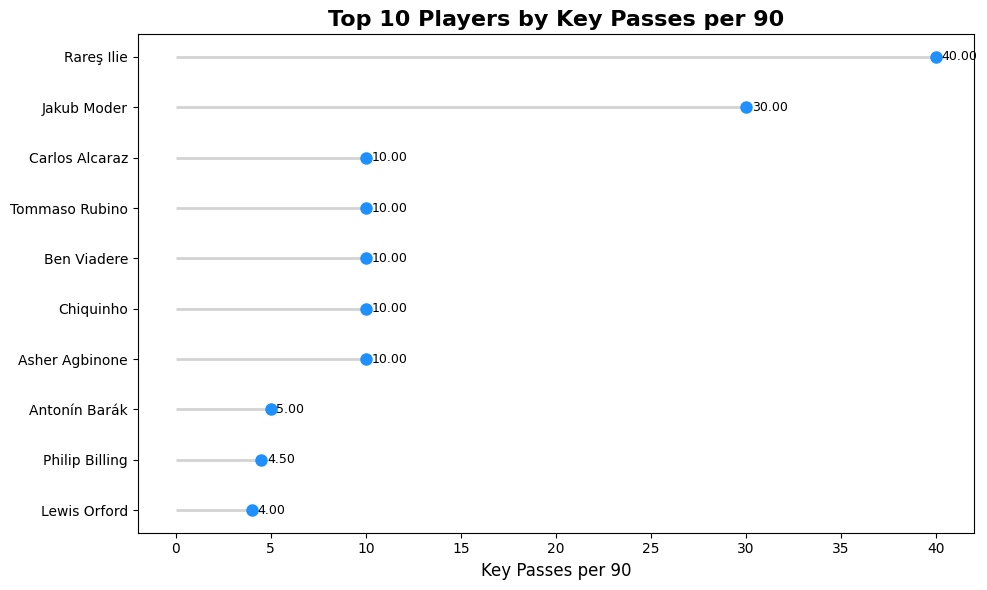

In [617]:
# Visualization: Top 10 Key Passes
plt.figure(figsize=(10,6))
plt.hlines(y=top_keypass['Player'], xmin=0, xmax=top_keypass['KP_per90'], color='lightgray', lw=2)
plt.plot(top_keypass['KP_per90'], top_keypass['Player'], "o", markersize=8, color="dodgerblue")

# Add value labels
for i, row in top_keypass.iterrows():
    plt.text(row['KP_per90'] + 0.3, row['Player'],
             f"{row['KP_per90']:.2f}", va='center', fontsize=9)

# Invert y-axis so highest is on top
plt.gca().invert_yaxis()

# Titles and labels
plt.title("Top 10 Players by Key Passes per 90", fontsize=16, weight='bold')
plt.xlabel("Key Passes per 90", fontsize=12)
plt.ylabel("")
plt.tight_layout()
plt.show()


In [618]:
#Player Ranking by Ball Progression
##Rank players by Carries
top_carries = data_light.sort_values('Carries', ascending=False)[
    ['Player','Squad','Carries']].head(10).reset_index(drop=True).rename(lambda x: x+1)
top_carries

,Player,Squad,Carries
1,Joshua Kimmich,Bayern Munich,2399
2,Pedri,Barcelona,2012
3,Pierre Højbjerg,Marseille,1950
4,Vitinha,Paris S-G,1756
5,Granit Xhaka,Leverkusen,1611
6,Angelo Stiller,Stuttgart,1588
7,Manuel Locatelli,Juventus,1559
8,Mattéo Guendouzi,Lazio,1549
9,Bruno Fernandes,Manchester Utd,1542
10,Éderson,Atalanta,1490


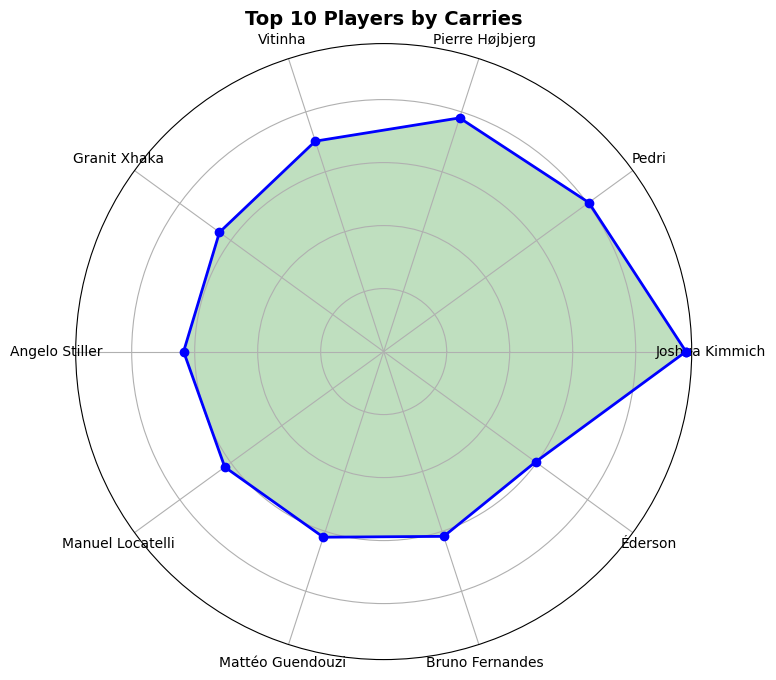

In [619]:
###Visualization: Top 10 players by Carries
players = top_carries['Player']
values = top_carries['Carries']

angles = np.linspace(0, 2 * np.pi, len(players), endpoint=False).tolist()
values = values.tolist()
values += values[:1]  # Close the circle
angles += angles[:1]

plt.figure(figsize=(8,8))
ax = plt.subplot(polar=True)
ax.plot(angles, values, 'o-', linewidth=2, color='blue')
ax.fill(angles, values, alpha=0.25, color='green')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(players, fontsize=10)
ax.set_yticklabels([])
plt.title("Top 10 Players by Carries", fontsize=14, weight='bold')
plt.show()


In [620]:
## Rank players by progressive Runs (PrgR)
top_prgR = data_light.sort_values('PrgR', ascending=False)[
    ['Player','Squad','PrgR']].head(10).reset_index(drop=True).rename(lambda x : x+1)
top_prgR

,Player,Squad,PrgR
1,Paul Nebel,Mainz 05,219
2,Romano Schmid,Werder Bremen,201
3,Julian Brandt,Dortmund,199
4,Giuliano Simeone,Atlético Madrid,189
5,Xavi Simons,RB Leipzig,185
6,Ismaila Sarr,Crystal Palace,183
7,Adrien Rabiot,Marseille,174
8,Justin Kluivert,Bournemouth,173
9,Lee Jae-sung,Mainz 05,165
10,Jamal Musiala,Bayern Munich,156


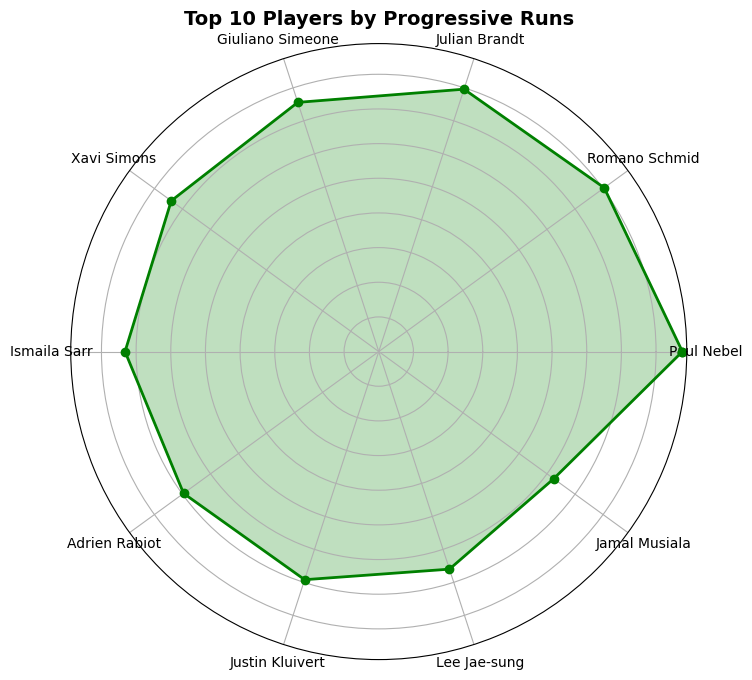

In [621]:
###Visualization: Top 10 players by Progressive Runs
players = top_prgR['Player']
values = top_prgR['PrgR']

angles = np.linspace(0, 2 * np.pi, len(players), endpoint=False).tolist()
values = values.tolist()
values += values[:1]  # Close the circle
angles += angles[:1]

plt.figure(figsize=(8,8))
ax = plt.subplot(polar=True)
ax.plot(angles, values, 'o-', linewidth=2, color='green')
ax.fill(angles, values, alpha=0.25, color='green')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(players, fontsize=10)
ax.set_yticklabels([])
plt.title("Top 10 Players by Progressive Runs", fontsize=14, weight='bold')
plt.show()

In [622]:
## Ranking players by the(Carries & PrgR)
# Rank each metric individually and average the ranks
progress_cols = ['Carries','PrgR']
data_light['progress_rank'] = data_light[progress_cols].rank(ascending=False).mean(axis=1)

# Top 10 Players by Combined Progression Rank
top_progressors = data_light.sort_values('progress_rank')[['Player','Squad'] + progress_cols].head(10).reset_index(drop=True).rename(lambda x : x+1)
top_progressors



,Player,Squad,Carries,PrgR
1,Pedri,Barcelona,2012,136
2,Romano Schmid,Werder Bremen,1315,201
3,Bruno Fernandes,Manchester Utd,1542,129
4,Jude Bellingham,Real Madrid,1229,143
5,Nicolò Barella,Inter,1393,133
6,Martin Ødegaard,Arsenal,1174,154
7,Adrien Rabiot,Marseille,1096,174
8,Tijjani Reijnders,Milan,1214,121
9,Enzo Fernández,Chelsea,1211,126
10,Bruno Guimarães,Newcastle Utd,1400,96


C:\Users\ancir\AppData\Local\Temp\ipykernel_15276\2711051952.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Carries', y='Player', data=top_progressors, palette="Blues_d", ax=axes[0])
C:\Users\ancir\AppData\Local\Temp\ipykernel_15276\2711051952.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PrgR', y='Player', data=top_progressors, palette="Greens_d", ax=axes[1])


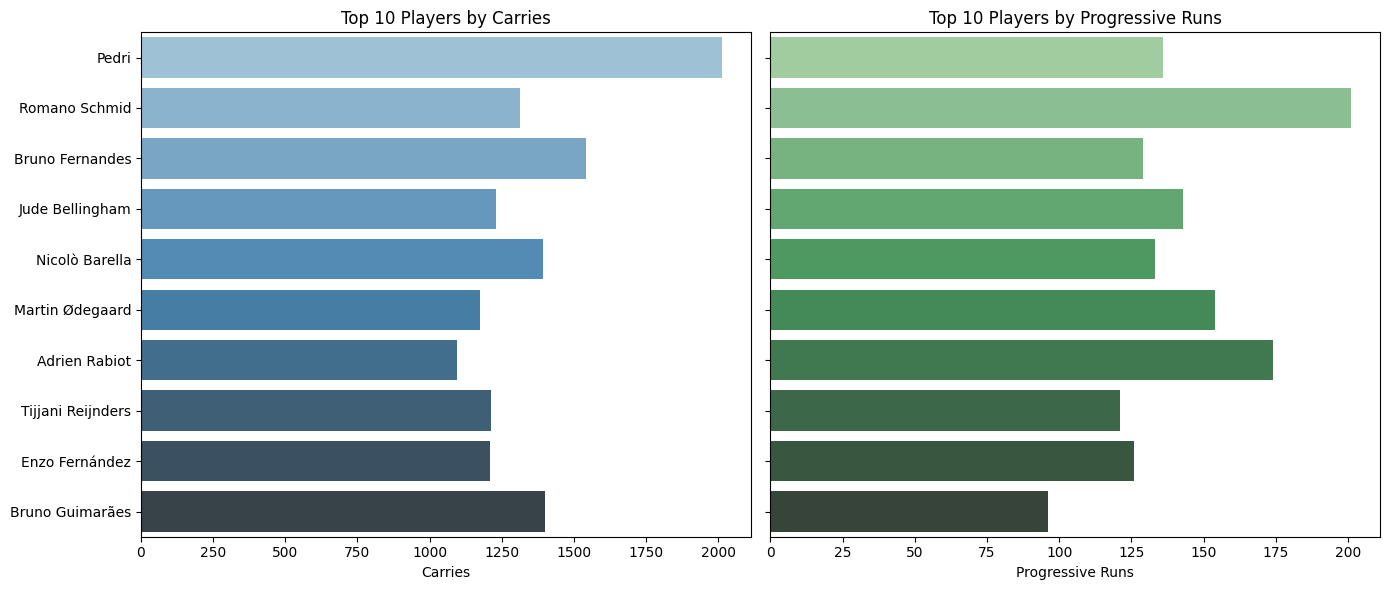

In [623]:
###Visualization the carries and PrgR
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)
axes = axes.flatten()
#Carries
sns.barplot(x='Carries', y='Player', data=top_progressors, palette="Blues_d", ax=axes[0])
axes[0].set_title("Top 10 Players by Carries")
axes[0].set_xlabel("Carries")
axes[0].set_ylabel("")

#Progressive Runs
sns.barplot(x='PrgR', y='Player', data=top_progressors, palette="Greens_d", ax=axes[1])
axes[1].set_title("Top 10 Players by Progressive Runs")
axes[1].set_xlabel("Progressive Runs")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

C:\Users\ancir\AppData\Local\Temp\ipykernel_15276\2489248825.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = top10_players["Player"], y = top10_players[feature], ax = axes[i], palette="viridis")
C:\Users\ancir\AppData\Local\Temp\ipykernel_15276\2489248825.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(top10_players["Player"], rotation=45, fontsize=8)
C:\Users\ancir\AppData\Local\Temp\ipykernel_15276\2489248825.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = top10_players["Player"], y = top10_players[feature], ax = axes[i], palette="viridis")
C:\Users\ancir\App

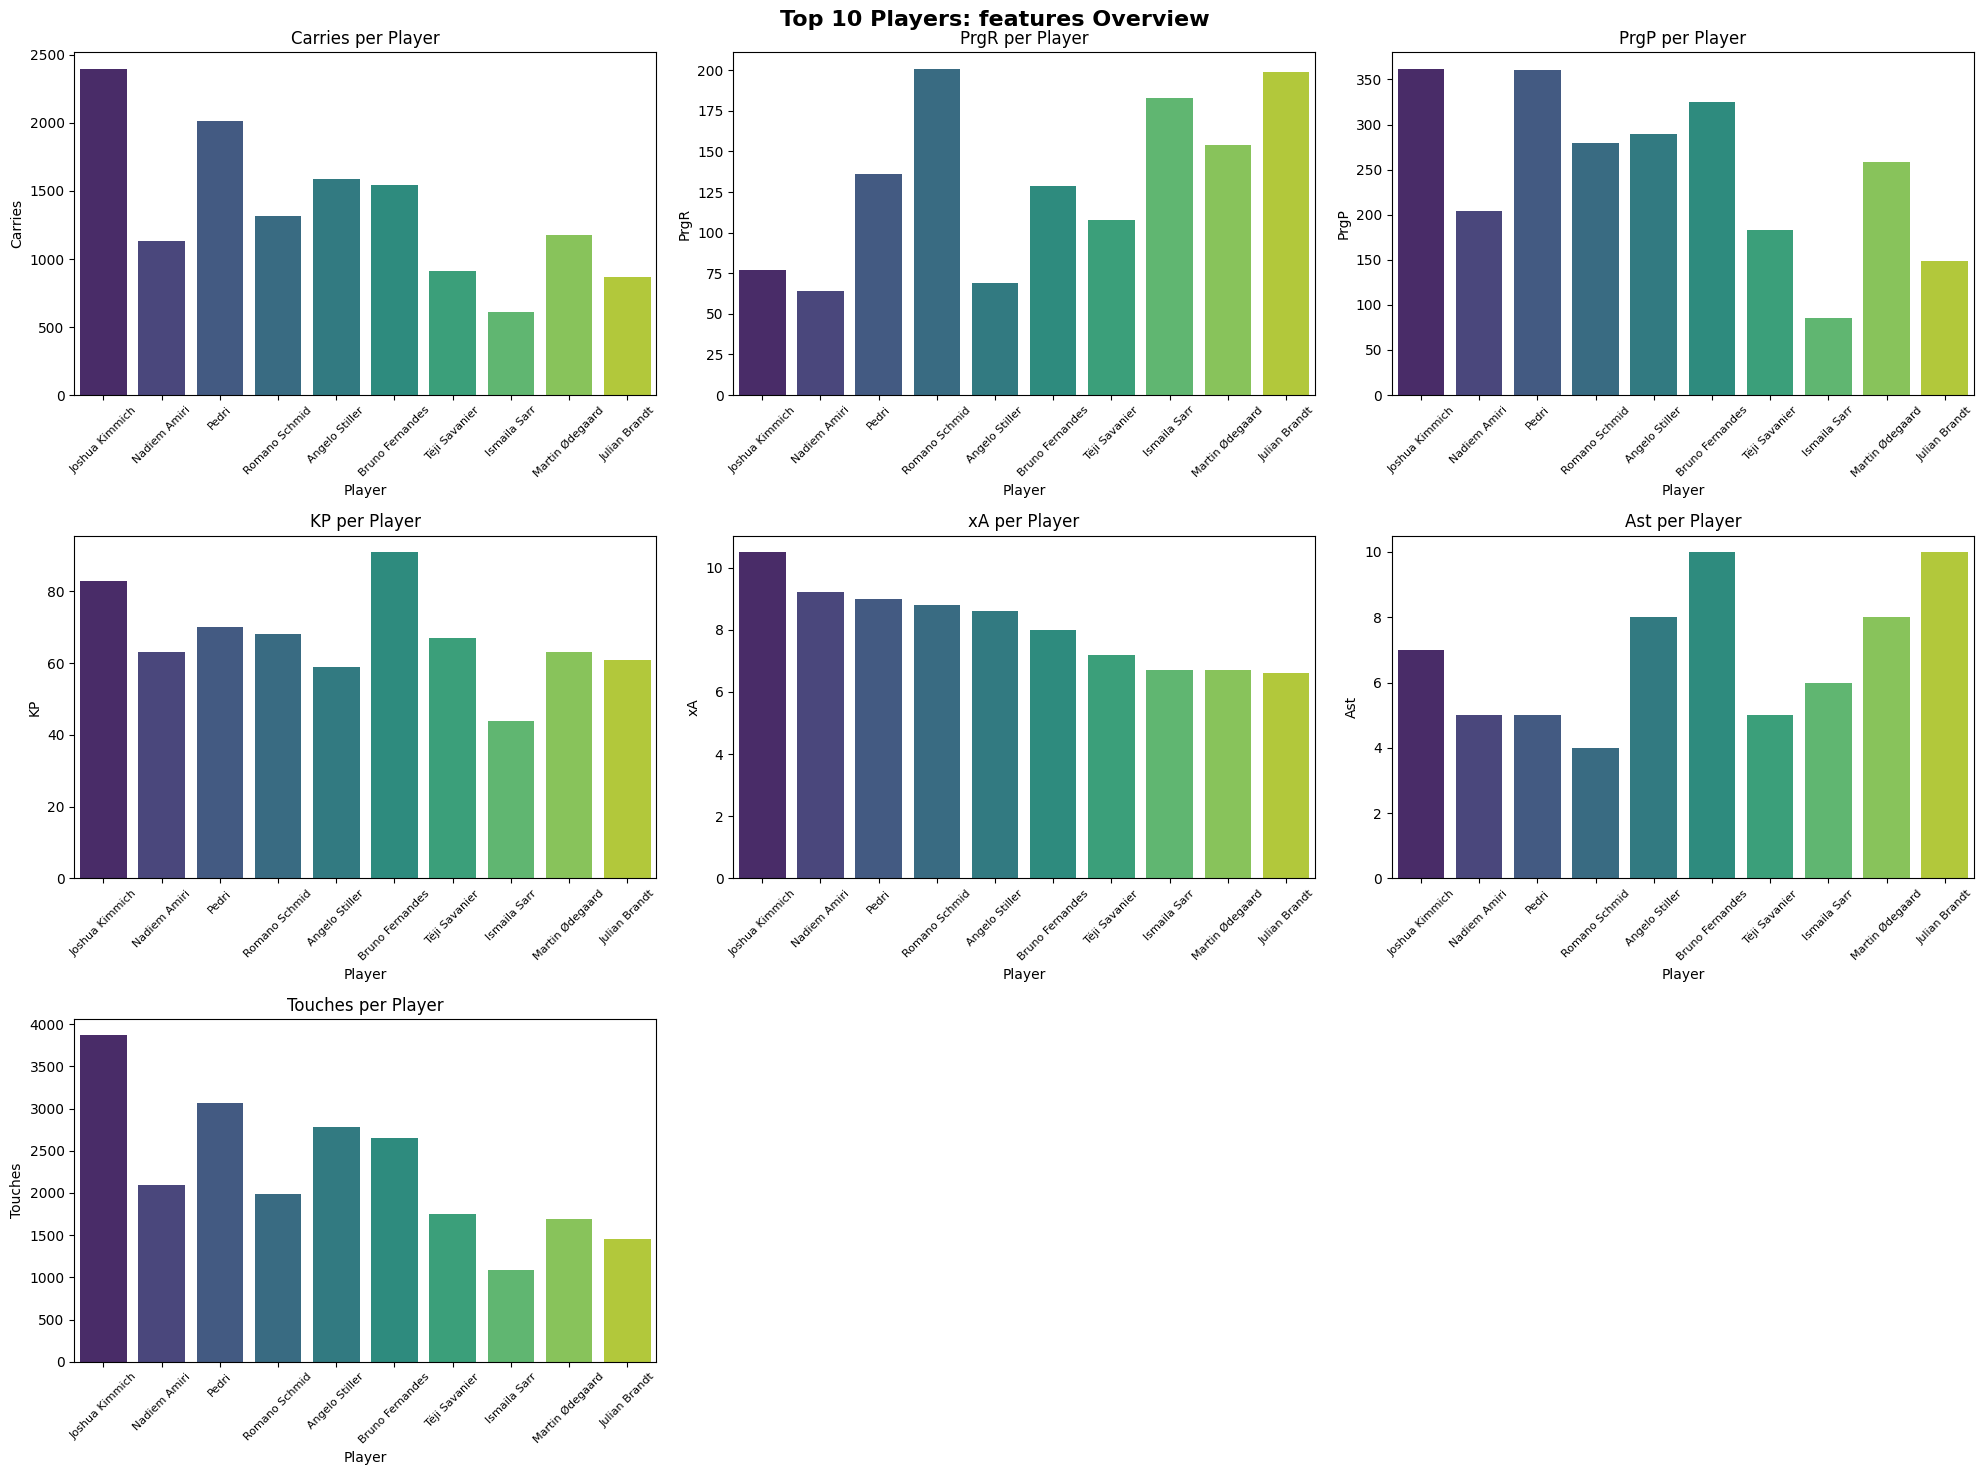

In [624]:
#Correlation Analysis
corr_features = ["Carries", "PrgR", "PrgP", "KP", "xA", "Ast", "Touches"]

# the top 10 players by xA
top10_players = data_light.sort_values("xA", ascending=False).head(10)
corr_matrix = top10_players[corr_features].corr()

# Subplots for each feature
fig, axes = plt.subplots(3, 3, figsize=(20,15))
axes = axes.flatten()

for i, feature in enumerate(corr_features):
    sns.barplot(x = top10_players["Player"], y = top10_players[feature], ax = axes[i], palette="viridis")
    axes[i].set_title(f"{feature} per Player")
    axes[i].set_xticklabels(top10_players["Player"], rotation=45, fontsize=8)

# Remove empty subplot
for j in range(len(corr_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Top 10 Players: features Overview", fontsize=16, weight="bold")
plt.tight_layout()
plt.show()


In [625]:
# we will creat a point system
data_light['points'] = (
    2 * data_light['KP'] +2 * data_light['Ast'] +data_light['Cmp%']
    -data_light['Mis']-0.5 * data_light['Dis']).apply(ceil)

greatest = data_light[['Age','Player','Nation','Squad','points']].sort_values(by='points', ascending=False).reset_index(drop=True).rename(lambda x:x+1)

greatest.head(10)


,Age,Player,Nation,Squad,points
1,29.0,Joshua Kimmich,GER,Bayern Munich,245
2,29.0,Bruno Fernandes,POR,Manchester Utd,214
3,23.0,Enzo Fernández,ARG,Chelsea,205
4,38.0,Luka Modrić,CRO,Real Madrid,203
5,23.0,Angelo Stiller,GER,Stuttgart,188
6,31.0,Granit Xhaka,SUI,Leverkusen,179
7,21.0,Pedri,ESP,Barcelona,172
8,30.0,Hakan Çalhanoğlu,TUR,Inter,172
9,23.0,Lucas Da Cunha,FRA,Como,171
10,27.0,Youri Tielemans,BEL,Aston Villa,171


C:\Users\ancir\AppData\Local\Temp\ipykernel_15276\1708580018.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(top_nations.index, rotation=45, fontsize=9)
C:\Users\ancir\AppData\Local\Temp\ipykernel_15276\1708580018.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(top_squads.index, rotation=45, fontsize=9)


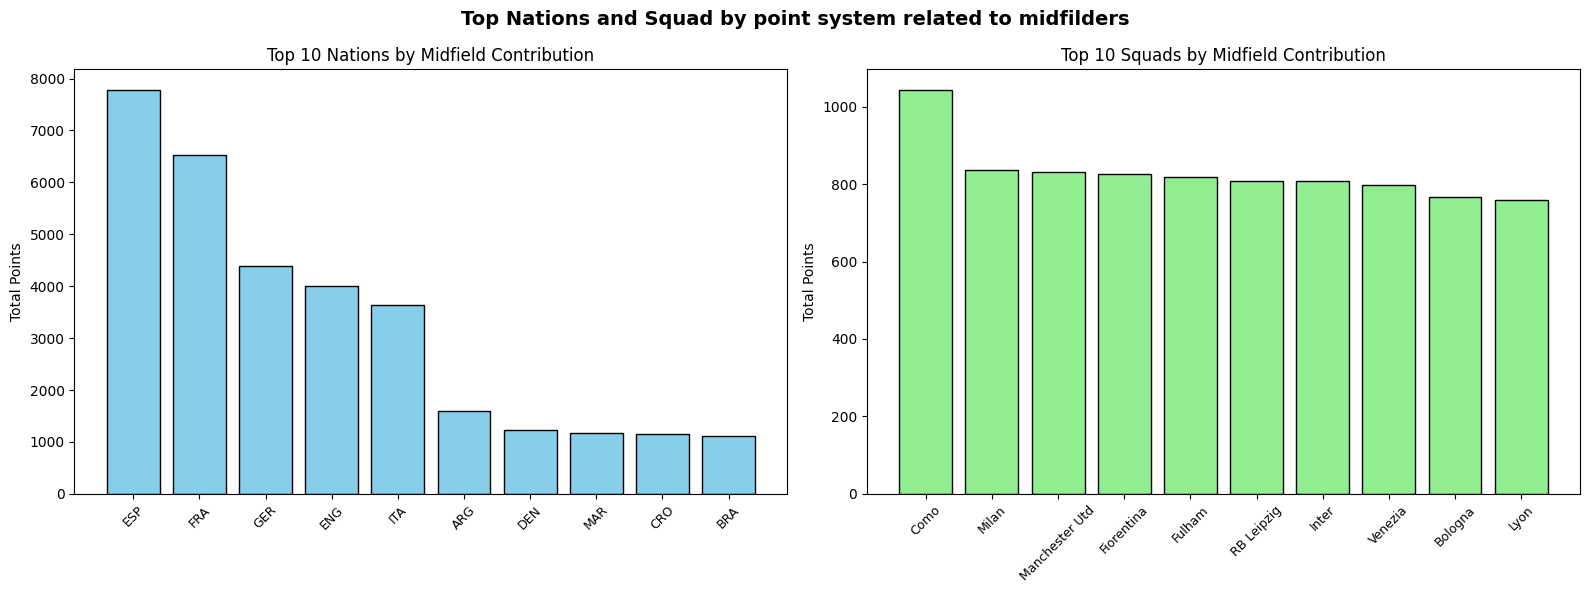

In [626]:
###Visualazation of top Nations and Squad by point system related to midfilders
# Top 10 Nations by total points
top_nations = greatest.groupby("Nation")["points"].sum().sort_values(ascending=False).head(10)

# Top 10 Squads by total points
top_squads = greatest.groupby("Squad")["points"].sum().sort_values(ascending=False).head(10)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Left: Nations
axes[0].bar(top_nations.index, top_nations.values, color="skyblue", edgecolor="black")
axes[0].set_title("Top 10 Nations by Midfield Contribution", fontsize=12)
axes[0].set_ylabel("Total Points")
axes[0].set_xticklabels(top_nations.index, rotation=45, fontsize=9)

# Right: Squads
axes[1].bar(top_squads.index, top_squads.values, color="lightgreen", edgecolor="black")
axes[1].set_title("Top 10 Squads by Midfield Contribution", fontsize=12)
axes[1].set_ylabel("Total Points")
axes[1].set_xticklabels(top_squads.index, rotation=45, fontsize=9)

plt.suptitle("Top Nations and Squad by point system related to midfilders", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()


C:\Users\ancir\AppData\Local\Temp\ipykernel_15276\1114809516.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\ancir\AppData\Local\Temp\ipykernel_15276\1114809516.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(top10_names, rotation=45, fontsize=6)
C:\Users\ancir\AppData\Local\Temp\ipykernel_15276\1114809516.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\ancir\AppData\Local\Temp\ipykernel_15276\1114809516.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].se

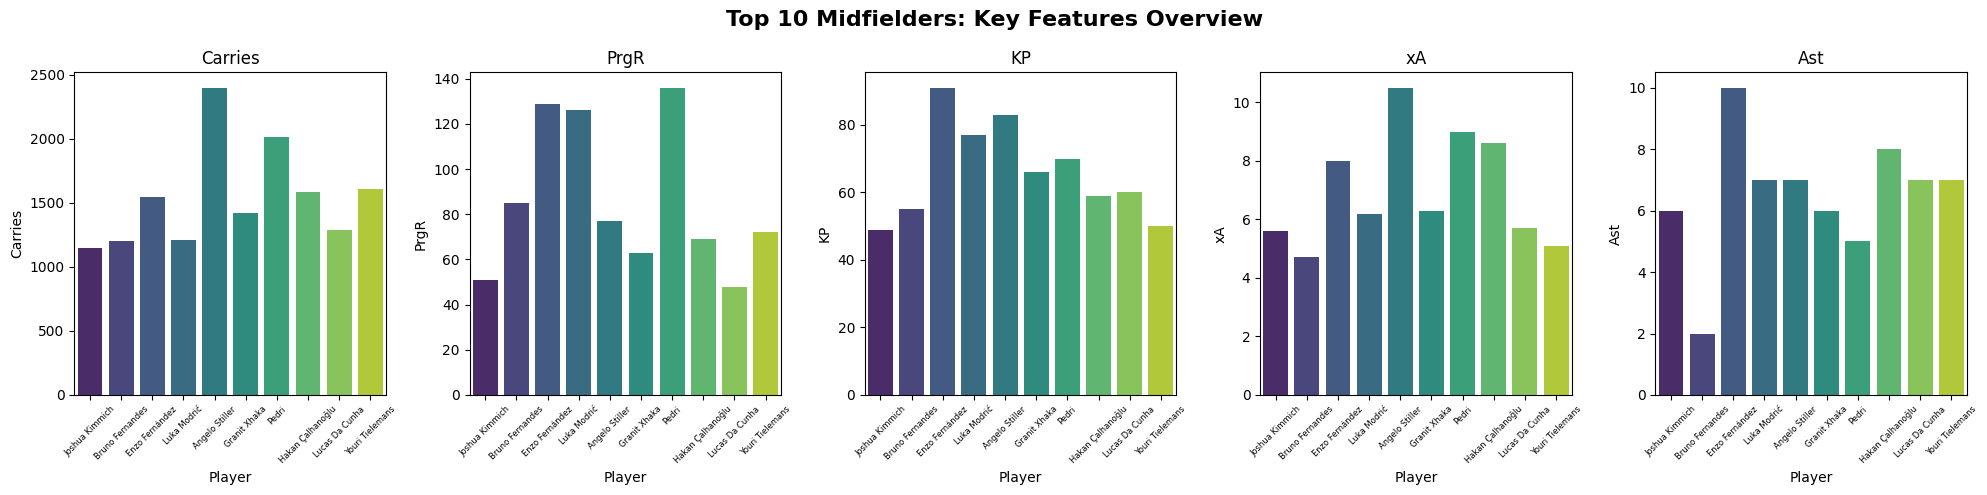

In [635]:
###Visualazation of Top 10 Midfielders: Key Features Overview
top10_players = greatest.head(10)
top10_names = top10_players['Player'].tolist()

# Features to visualize
features = ['Carries','PrgR','KP','xA','Ast']

fig, axes = plt.subplots(1, 5, figsize=(20,5))

for i, feature in enumerate(features):
    sns.barplot(
        x='Player', 
        y=feature, 
        data=data_light[data_light['Player'].isin(top10_names)], 
        ax=axes[i],
        palette="viridis"
    )
    axes[i].set_title(feature, fontsize=12)
    axes[i].set_xticklabels(top10_names, rotation=45, fontsize=6)

plt.suptitle("Top 10 Midfielders: Key Features Overview", fontsize=16, weight="bold")
plt.tight_layout()
plt.show()


In [628]:
#Weakness score
##High Mis + Dis reduces effectiveness, low creativity reduces impact
data_light['weakness_score'] = (data_light['Mis'] + data_light['Dis']) - (data_light['KP'] + data_light['Ast'])

In [629]:
##Rank midfielders by weakness_score (highest = weakest)
weak_mf = data_light.sort_values('weakness_score', ascending=False)[['Player','Squad','Nation','weakness_score']].head(10).reset_index(drop=True).rename(lambda x :x+1)
weak_mf


,Player,Squad,Nation,weakness_score
1,Hamed Junior Traorè,Auxerre,CIV,94
2,Scott McTominay,Napoli,SCO,86
3,Andy Diouf,Lens,FRA,82
4,Manu Koné,Roma,FRA,79
5,Oihan Sancet,Athletic Club,ESP,79
6,Javier Guerra,Valencia,ESP,78
7,Bruno Guimarães,Newcastle Utd,BRA,74
8,Mauro Arambarri,Getafe,URU,72
9,Paul Nebel,Mainz 05,GER,71
10,Xavi Simons,RB Leipzig,NED,71


C:\Users\ancir\AppData\Local\Temp\ipykernel_15276\3661233158.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


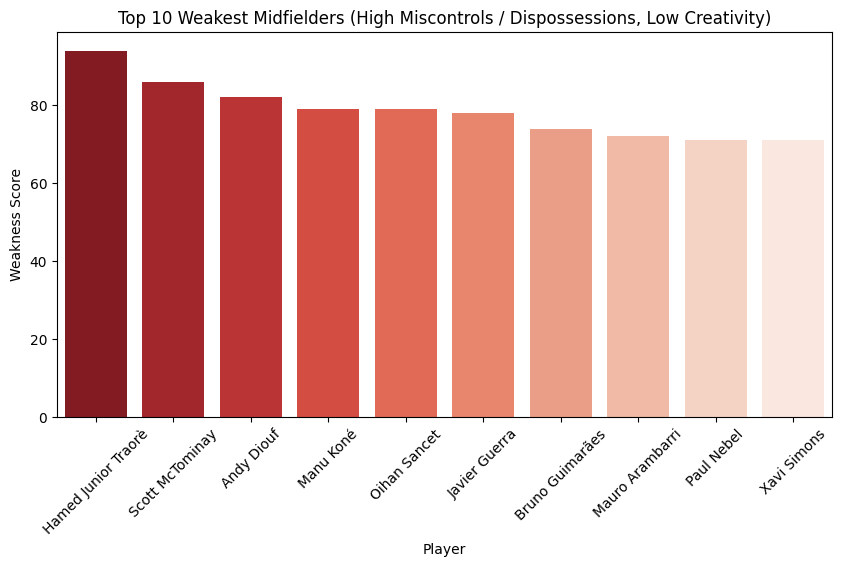

In [630]:
###Visualization of Weakest Midfielders
plt.figure(figsize=(10,5))
sns.barplot(
    x='Player',
    y='weakness_score',
    data=weak_mf,
    palette='Reds_r'  # Red shades for weakness
)
plt.xticks(rotation=45)
plt.ylabel("Weakness Score")
plt.title("Top 10 Weakest Midfielders (High Miscontrols / Dispossessions, Low Creativity)")
plt.show()


In [631]:
##Weakness by Squad 
squad_weak = data_light.groupby('Squad')['weakness_score'].mean().sort_values(ascending=False).head(10)

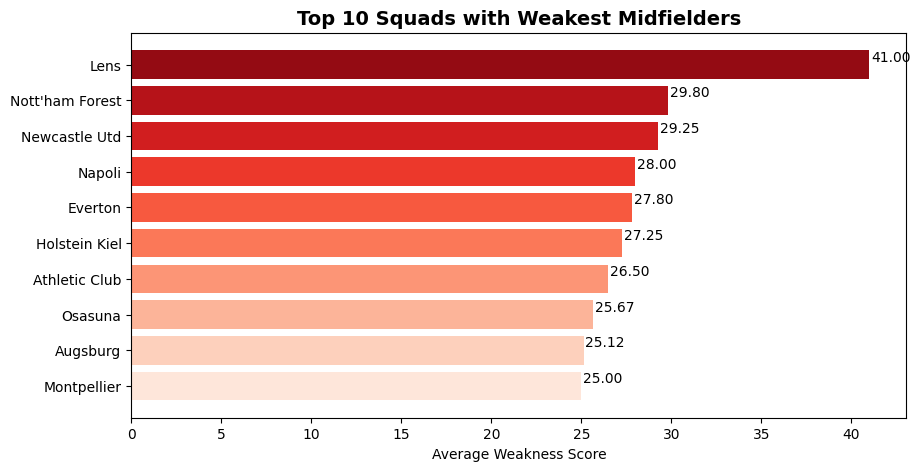

In [632]:
###Visualization of weakest Squads
squad_weak_sorted = squad_weak.sort_values(ascending=False)
colors = list(reversed(sns.color_palette("Reds", len(squad_weak_sorted))))
plt.figure(figsize=(10,5))
bars = plt.barh(squad_weak.index, squad_weak.values, color=colors)
plt.xlabel("Average Weakness Score")
plt.title("Top 10 Squads with Weakest Midfielders", fontsize=14, weight='bold')

# Add value labels
for bar in bars:
    plt.text(bar.get_width() + 0.1, bar.get_y() + 0.3, f'{bar.get_width():.2f}', fontsize=10)

plt.gca().invert_yaxis()
plt.show()


In [633]:
# Average weakness per nation
nation_weak = data_light.groupby("Nation")["weakness_score"].mean().sort_values(ascending=False).head(10)


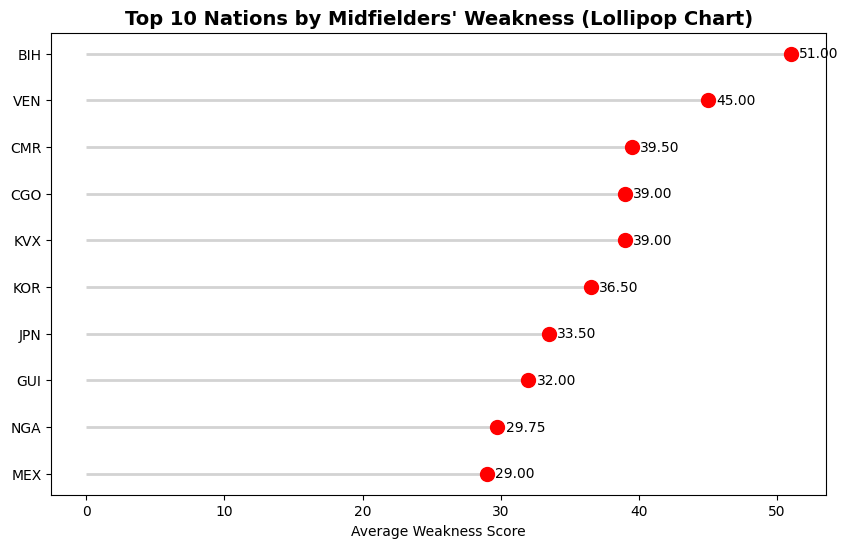

In [634]:
###Visualization of weakest Nation
plt.figure(figsize=(10,6))

plt.hlines(y=nation_weak.index, xmin=0, xmax=nation_weak.values, color='lightgray', linewidth=2)
plt.plot(nation_weak.values, nation_weak.index, "o", color="red", markersize=10)

for i, value in enumerate(nation_weak.values):
    plt.text(value + 0.6,nation_weak.index[i], f"{value:.2f}", va='center', fontsize=10)

plt.xlabel("Average Weakness Score")
plt.title("Top 10 Nations by Midfielders' Weakness (Lollipop Chart)", fontsize=14, weight="bold")
plt.gca().invert_yaxis()  # highest weakness on top
plt.show()